# Introduction tutorial for Machine Learning in Nuclear Physics and Experiment
**[Kaciel Béraud](mailto:beraud@lpccaen.in2p3.fr)**, Laboratoire de Physique Corpusculaire de Caen, Caen, France.

Date: **17 September 2025**

## Introduction


This tutorial aim to introduce the basic tools used for Machine Learning and Data processing. During this semester, we will use the Python language with dedicated libraries, listed below. 

During this tutorial, we will look at **NumPy** and **pandas** for data processing and **scikit-learn** or **scipy** for an introduction to fitting.

You should have a google account to get access to [Google Colab](https://colab.research.google.com/), you can choose to use your personal computer but no help will be given to make the libraries works.

## Required Libraries

Here we list several useful Python libraries we will be using during the year:

* [NumPy](https://www.numpy.org/) is a highly popular library for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays

* [pandas](https://pandas.pydata.org/) library provides high-performance, easy-to-use data structures and data analysis tools 

* [Scipy](https://www.scipy.org/) (pronounced “Sigh Pie”) is a Python-based ecosystem of open-source software for mathematics, science, and engineering. 

* [scikit-learn](https://scikit-learn.org/stable/) has simple and efficient tools for machine learning, data mining and data analysis

* [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces publication quality figures in a variety of hardcopy formats and interactive environments across platforms.

* [PyTorch](https://pytorch.org/) is a high-level ML API, implementing Tensors and Neural Networks with built-in autograd methods

* [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) is a ML framework developped around PyTorch to simplify the creation of models.

You can find many alternatives, such as:

* [TensorFlow](https://www.tensorflow.org/) is a Python library for fast numerical computing created and released by Google

* [Keras](https://keras.io/) is a high-level neural networks API, written in Python and capable of running on top of TensorFlow, CNTK, or Theano

## NumPy

[Numpy](http://www.numpy.org/) provides an easy and efficient way to handle arrays in Python. This library will be extensively used by [PyTorch](https://pytorch.org/) for handling tensors.

The standard way to import this library is as

In [16]:
import numpy as np

Here follows a simple example where we define a numpy array of size 3;

In [17]:
x = np.array([1, 2, 3])
print(x)

[1 2 3]


Note the use of the square brackets, it's because we define the array based on a Python list. You can define complex Python list and then pass it as a NumPy array;

In [18]:
l = [*range(10,64,4)]
l = l[3:-4]
x = np.array(l)
print(l, x)
print(type(l), type(x))


[22, 26, 30, 34, 38, 42, 46] [22 26 30 34 38 42 46]
<class 'list'> <class 'numpy.ndarray'>


But NumPy is equipped with a lot of useful functions to create arrays and applying mathematical operations;

In [19]:
n = 10

# We sample n value on a normal distribution
x = np.random.normal(size=10)
print("Normal distribution:", x, '\n')

# We sample n value on a uniform distribution [0;1)
x = np.random.rand(10)
print("Uniform distribution:", x, '\n')

# We sample n value on a uniform distribution [0;1) on log
x = np.log(np.random.rand(10))
print("Log distribution:", x, '\n')

# We create a evenly distributed array from 0 to 9 with 10 step
x = np.linspace(0, 9, 10)
print("Uniform range:", x, '\n')

# We create a evenly distributed log array from  power 0 to power 9 with 10 step
x = np.logspace(-3, 9, 13)
print("Log range:", x, '\n')

Normal distribution: [ 1.36685509 -0.34444577 -0.97419267  1.35877577  0.04082322 -0.37001174
 -1.08654728 -1.41312929 -1.82289352 -0.20496627] 

Uniform distribution: [0.01942078 0.21029712 0.94050141 0.72251425 0.6404752  0.04544501
 0.1988817  0.91335194 0.86861498 0.7461023 ] 

Log distribution: [-0.98287048 -0.85305172 -6.56369948 -3.69871885 -2.82057549 -0.31978375
 -0.02297168 -0.67689822 -0.65473741 -0.39909884] 

Uniform range: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.] 

Log range: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06
 1.e+07 1.e+08 1.e+09] 



Mathematical operations on the array are way more efficient in NumPy than in pure Python, this is because the code is vectorized and does not requires looping. We can compare the same operation using pure Python and Numpy;

In [20]:
import time
import math

start = time.time() 
x = np.log(np.linspace(1, 1e3, int(1e5)))
end = time.time()
print(f"Using NumPy: {end-start:.5f} seconds")

start = time.time() 
x = np.linspace(1, 1e3, int(1e5))
for i in range(len(x)) :
    x[i] = math.log(x[i])
end = time.time()
print(f"Using Python: {end-start:.5f} seconds")

Using NumPy: 0.00154 seconds
Using Python: 0.02069 seconds


Since the computation are vectorized, we can refer to a NumPy's array of dimension 1 as a **vector**.

## Matrices in Python

Since now we have defined a vector, we can now expand to matrices. We can define a $3 \times 3$ real matrix $\boldsymbol{A}$ as;

In [21]:
A = np.array([[1, 2, 3], [4, 8, 12], [-1, -3, -5]])
print(A)

[[ 1  2  3]
 [ 4  8 12]
 [-1 -3 -5]]


You can also create matrix from array, it's useful when you have to arrange the data from a vector and put it as a matrix for computation purpose. It can be done as

In [22]:
A = np.arange(16).reshape(4,4)
print(A)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


The function `arange()` is the numpy equivalent of the `range()` function in Python, it gives you a 1D array with a sequence of element from start to stop, evenly distributed according to a step. This function as more power than Python's one, because it's not limited to integers.

The method `reshape()` allow you to change the shape of the array, here we transform the vector into a square matrix of size 4. The new shape should have the exact same number of element for it to works.

You can access elements by using the bracket operator `[]`;

In [23]:
print("Access to a single element:", A[2][0], "or", A[2,0])
print("Access to a whole column:", A[:,2])
print("Access to a whole row:", A[2,:], "or", A[2])

Access to a single element: 8 or 8
Access to a whole column: [ 2  6 10 14]
Access to a whole row: [ 8  9 10 11] or [ 8  9 10 11]


NumPy contains many other functionalities to slice, subdivide, split or merge arrays. We strongly recommend that you look up the [Numpy website](http://www.numpy.org/) for more details.

One powerful functionality of the `[]` access operator, is the possibility to choose a range and the step;

In [24]:
x = np.arange(64)
print(x)

# slice the array from 6 to 23
y = x[6:23]
print(y)

# slice the array from 43 to the end
w = x[43:-1] # -1 can be ommited, has [43:]
print(w)

# slice from 12 to 46 with a step of 2
z = x[12:46:2]
print(z)

# slice from 8 to 50 with a reverseed step of 2
v = x[50:8:-1] # note that we need to reverse the index here
print(v)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]
[ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
[43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62]
[12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44]
[50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27
 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9]


### Default initialization of matrices

You often want to create a default empty matrix of the size of your choice to then fill it with your values. You can create a matrix as;

In [25]:
# Creates a 3 by 3 matrix and set all element to zero
A = np.zeros((3, 3))
print(A)

# Creates a 3 by 3 matrix and set all element to one
A = np.ones((3, 3))
print(A)

# Creates a 3 by 3 matrix and set all element to a predetermined value
A = np.full((3, 3), 42.)
print(A)

# Creates a unitary matrix of size 3
# When not given a square size, it will fill the diagonal with ones and left the rest with zeroes
A = np.eye(3, 3)
print(A)

# Create an empty matrix of size 3 by 3, but do not initialized the values
A = np.empty((3, 3))
print(A)

# Not that the values of the matrix are the same as the previous one

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
[[42. 42. 42.]
 [42. 42. 42.]
 [42. 42. 42.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Note the use of `()` to create a tuple with the size. You can use a single integer to make a square matrix of size $n$, not all function do take a type with the dimensions.

### Memory management

Because Python only do references, it's easy to not copy and object and modify the wrong one with the one we want to change. Take a look at the following code, you will see that the modification made on the first matrix impact the second one as well;

In [26]:
# Init A matrix
A = np.full((6, 4), 7.3)
print("Matrix A:\n", A)

# Make B matrix
B = A
print("Matrix B:\n", B)

# Modify the A matrix
A[2, 3] = 10.3
print("Matrix A:\n", A)

# But the B matrix is also modified!
print("Matrix B:\n", B)

Matrix A:
 [[7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]]
Matrix B:
 [[7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]]
Matrix A:
 [[ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3 10.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]]
Matrix B:
 [[ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3 10.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]]


To avoid problems with the references of object, when you want to do a true **copy** of the object and not only an **alias** of it, you can simply use the method;

In [27]:
# Init A matrix
A = np.full((6, 4), 7.3)
print("Matrix A:\n", A)

# Make B matrix
B = A.copy() # <-----| copy method here
print("Matrix B:\n", B)

# Modify the A matrix
A[2, 3] = 10.3
print("Matrix A:\n", A)

# Now B is not modified!
print("Matrix B:\n", B)

Matrix A:
 [[7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]]
Matrix B:
 [[7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]]
Matrix A:
 [[ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3 10.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]
 [ 7.3  7.3  7.3  7.3]]
Matrix B:
 [[7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]
 [7.3 7.3 7.3 7.3]]


## Exercise 1

* Create a numpy array starting from 6 to 58 with a step of 4.

* Then reverse the array.

In [28]:
# Exercise 1
A = np.arange(6,59,4)
print('La liste obtenue est \n', A)
print('La liste inversé est \n', np.flip(A))

La liste obtenue est 
 [ 6 10 14 18 22 26 30 34 38 42 46 50 54 58]
La liste inversé est 
 [58 54 50 46 42 38 34 30 26 22 18 14 10  6]


## Exercise 2

* Create a 3D matrix of size $5 \times 6 \times 8$ full of zeros.

* Set the second half of the matrix along the z-axis to 2.4.

* Add normal random noise to every cell of the matrix.

In [29]:
# Exercise 2
JOSE_MATRIX = np.zeros((5,6,8))
print('la matrice de jose est \n', JOSE_MATRIX)
JOSE_MATRIX[:,:,4:] = 2.4
print(JOSE_MATRIX[1,1,6])



la matrice de jose est 
 [[[0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0.]]]
2.4


## Exercise 3

* Create a 2D matrix of $30 \times 30$ representing a 2D gaussian distribution.

Plot it using **matplotlib**'s `pyplot.imshow` function.

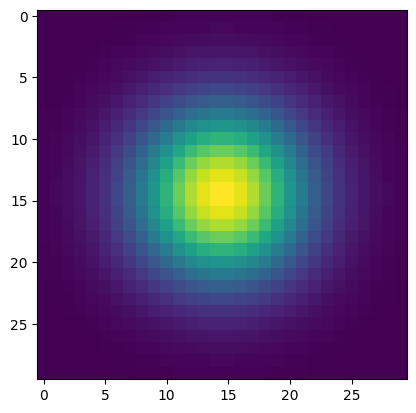

In [42]:
import numpy as np
from scipy.stats import multivariate_normal
from matplotlib import pyplot as plt

x = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(x, x)

positions = np.dstack((X, Y))

gaussian = multivariate_normal(
    mean=[0, 0],
    cov=[[1, 0], [0, 1]]
).pdf(positions)

gaussian = gaussian/gaussian.sum()

plt.imshow(gaussian)


## Pandas

Another useful Python package is [pandas](https://pandas.pydata.org/), which is an open source library providing high-performance, easy-to-use, general purpose data structures and operations in Python, it is built upon [NumPy](https://numpy.org/). **pandas** Stands for **PANel DAta**, a term borrowed from econometrics. This library provide operation manipulating numerical tables and time series. 

**pandas** has two main classes, the **DataFrame** class with two-dimensional data objects and tabular data organized in columns and rows. The second main class is the **Series** which focus on one-dimensional data objects. Using both classes, it allow you to easily index, arrange, slice and merge data.

**pandas** allows you also to perform mathematical operations on the data, spanning from reshaping of vectors and matrices, custom operations over rows and columns to statistical operations.

We will see how we can create, modify and managed tables of some labeled data using pandas. We start by importing it with the shorthand **pd**;

In [ ]:
import pandas as pd
from IPython.display import display # to show the dataframes nicely

In [ ]:
data = {'First Name': ["Frodo", "Bilbo", "Aragorn II", "Samwise"],
        'Last Name': ["Baggins", "Baggins","Elessar","Gamgee"],
        'Place of birth': ["Shire", "Shire", "Eriador", "Shire"],
        'Date of Birth T.A.': [2968, 2890, 2931, 2980]
        }
data_pandas = pd.DataFrame(data)
display(data_pandas)

,First Name,Last Name,Place of birth,Date of Birth T.A.
0,Frodo,Baggins,Shire,2968
1,Bilbo,Baggins,Shire,2890
2,Aragorn II,Elessar,Eriador,2931
3,Samwise,Gamgee,Shire,2980


It's standard practice to import **pandas** as **pd**, it allow you to make cleaner code. We define a dictionnary, containing list of datas and reorganize the data into a **DataFrame** and we finally print it nicely with the function **display**.

The keys of the dictionnary become the label of the columns and each index of the list are now a row index. We can easily change the labels name and index values by redefining the later;

In [ ]:
data_pandas = pd.DataFrame(data, index = ["Ringbearer", "Previous Hero", "King", "Sidekick"])
display(data_pandas)

,First Name,Last Name,Place of birth,Date of Birth T.A.
Ringbearer,Frodo,Baggins,Shire,2968
Previous Hero,Bilbo,Baggins,Shire,2890
King,Aragorn II,Elessar,Eriador,2931
Sidekick,Samwise,Gamgee,Shire,2980


Thereafter we can display the content of the renamed row with the index **King**;

In [ ]:
display(data_pandas.loc["King"])

First Name            Aragorn II
Last Name                Elessar
Place of birth           Eriador
Date of Birth T.A.          2931
Name: King, dtype: object

Alternatively, you still can fetch the row by there numerical index using;

In [ ]:
display(data_pandas.iloc[2])

First Name            Aragorn II
Last Name                Elessar
Place of birth           Eriador
Date of Birth T.A.          2931
Name: King, dtype: object

You can just like in **NumPy**, select a column instead of a row

In [ ]:
display(data_pandas.loc[:, "First Name"]) # with label
display(data_pandas.iloc[:, 0]) # with index

Ringbearer            Frodo
Previous Hero         Bilbo
King             Aragorn II
Sidekick            Samwise
Name: First Name, dtype: object

Ringbearer            Frodo
Previous Hero         Bilbo
King             Aragorn II
Sidekick            Samwise
Name: First Name, dtype: object

One might also want to access a single value in the data, this can be achieve in a few different way;

In [ ]:
print(data_pandas.at["Ringbearer", "Last Name"]) # with labels
print(data_pandas.iat[0, 1]) # with index

Baggins
Baggins


Note that it's not possible to access a single element mixing a label and a numerical index, you can only use one type at a time.

Also note that you can access element using the `[]` operator instead of `.loc[]`, but chaining brackets operator (`df['one']['second']`) is not possible anymore in newer version of **pandas**, you have to do this: `df.loc[:, ('one', 'second')]`. See [this](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy) for me information on it.

You can easily append some new data in a **DataFrame**, you can either add rows or columns as;

In [ ]:
# Add a new data row
new_dwarf = {'First Name': ["Gimli"],
              'Last Name': [None],
              'Place of birth': ["Erud Luin"],
              'Date of Birth T.A.': [2879]
              }
data_pandas = pd.concat([data_pandas, pd.DataFrame(new_dwarf, index=['Dwarf'])])
display(data_pandas)

# Add a new column
data_pandas["Species"] = ["Hobbit", "Hobbit", "Human", "Hobbit", "Dwarf"]
display(data_pandas)

,First Name,Last Name,Place of birth,Date of Birth T.A.
Ringbearer,Frodo,Baggins,Shire,2968
Previous Hero,Bilbo,Baggins,Shire,2890
King,Aragorn II,Elessar,Eriador,2931
Sidekick,Samwise,Gamgee,Shire,2980
Dwarf,Gimli,None,Erud Luin,2879


,First Name,Last Name,Place of birth,Date of Birth T.A.,Species
Ringbearer,Frodo,Baggins,Shire,2968,Hobbit
Previous Hero,Bilbo,Baggins,Shire,2890,Hobbit
King,Aragorn II,Elessar,Eriador,2931,Human
Sidekick,Samwise,Gamgee,Shire,2980,Hobbit
Dwarf,Gimli,None,Erud Luin,2879,Dwarf


## Representing the data

Now we will see examples where we use a **DataFrame** functionality to handle arrays, with more interesting values for our field, namely numbers. A **DataFrame** can be created with a lot of initial object, most of them are array-like, this means we can create a **DataFrame** using a **NumPy** array or matrix.

In this example, we will set up a matrix of size $12 \times 7$ and computes statistical values such as mean and standard deviation of each column. We will also do more complex matrix operations.

In [ ]:
np.random.seed(100) # set a seed to get the same result each time

rows = 12
cols = 7

A = np.random.randn(rows, cols)
df = pd.DataFrame(A)

# Show some information
display(df)
print(df.sum())
print(df.std())
display(df**2)

,0,1,2,3,4,5,6
0,-1.749765,0.342680,1.153036,-0.252436,0.981321,0.514219,0.221180
1,-1.070043,-0.189496,0.255001,-0.458027,0.435163,-0.583595,0.816847
2,0.672721,-0.104411,-0.531280,1.029733,-0.438136,-1.118318,1.618982
3,1.541605,-0.251879,-0.842436,0.184519,0.937082,0.731000,1.361556
4,-0.326238,0.055676,0.222400,-1.443217,-0.756352,0.816454,0.750445
5,-0.455947,1.189622,-1.690617,-1.356399,-1.232435,-0.544439,-0.668172
6,0.007315,-0.612939,1.299748,-1.733096,-0.983310,0.357508,-1.613579
7,1.470714,-1.188018,-0.549746,-0.940046,-0.827932,0.108863,0.507810
8,-0.862227,1.249470,-0.079611,-0.889731,-0.881798,0.018639,0.237845
9,0.013549,-1.635529,-1.044210,0.613039,0.736205,1.026921,-1.432191


0   -3.906499
1   -0.198157
2   -3.244016
3   -5.244759
4    0.691306
5   -0.790150
6    3.456150
dtype: float64
0    1.131501
1    0.860075
2    0.896228
3    0.904752
4    1.038222
5    0.812032
6    1.024993
dtype: float64


,0,1,2,3,4,5,6
0,3.061679,0.117430,1.329492,0.063724,0.962990,0.264421,0.048920
1,1.144993,0.035909,0.065026,0.209789,0.189367,0.340583,0.667239
2,0.452553,0.010902,0.282259,1.060349,0.191963,1.250636,2.621102
3,2.376547,0.063443,0.709698,0.034047,0.878123,0.534362,1.853835
4,0.106431,0.003100,0.049462,2.082875,0.572069,0.666597,0.563167
5,0.207888,1.415201,2.858185,1.839818,1.518895,0.296414,0.446453
6,0.000054,0.375694,1.689345,3.003620,0.966899,0.127812,2.603636
7,2.162999,1.411386,0.302221,0.883687,0.685472,0.011851,0.257871
8,0.743436,1.561175,0.006338,0.791622,0.777568,0.000347,0.056570
9,0.000184,2.674956,1.090374,0.375817,0.541998,1.054568,2.051170


Here's a list of common statistical operation you can do on the different kind of **pandas** object, like a **DataFrame** but not limited to:

* `sum()`; sum values of object

* `count()`; count non-NA/null values of each object

* `median()`; median value of each object

* `quantile([0.25, 0.75])`; quantiles of each objects

* `min()`; minimum value in each object

* `max()`; maximum value in each object

* `mean()`; mean value of each object

* `var()`; variance of each object

* `std()`; standard deviation of each object

Most of these function are summarized in a simple method, `describe()`. it allow to get a clear summary of the statistical distribution in the **DataFrame**.

In [ ]:
display(df.describe())

,0,1,2,3,4,5,6
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,-0.325542,-0.016513,-0.270335,-0.437063,0.057609,-0.065846,0.288013
std,1.131501,0.860075,0.896228,0.904752,1.038222,0.812032,1.024993
min,-1.841188,-1.635529,-1.690617,-1.733096,-1.232435,-1.566688,-1.613579
25%,-1.129281,-0.342144,-0.892879,-1.044134,-0.841399,-0.558935,-0.001158
50%,-0.391092,-0.024368,-0.431529,-0.573622,-0.001486,0.063751,0.629127
75%,0.178342,0.419713,0.230550,0.291649,0.786424,0.568414,0.838879
max,1.541605,1.249470,1.299748,1.029733,2.034608,1.026921,1.618982


**DataFrames** have also built-in plotting function, that may allow you to look up what type of data you have. But these capabilities are limited and you're better off using another library, like [matplotlib](https://matplotlib.org/), [seaborn](https://seaborn.pydata.org/) or more interactive ones like [plotly](https://plotly.com/). Each library has its pros and cons, you may choose one depending on your current problem.

You can quickly plot a dataframe as

,0,1,2,3
count,500.000000,500.000000,500.000000,500.000000
mean,-2.283467,0.219262,3.507977,-5.854800
std,0.653121,1.700124,0.100180,2.343618
min,-4.225973,-4.616809,3.218135,-11.835445
25%,-2.660406,-0.944876,3.439459,-7.509644
50%,-2.297907,0.185335,3.505601,-5.860732
75%,-1.844404,1.290987,3.571708,-4.352315
max,0.014764,5.205778,3.792966,2.769189


<Axes: ylabel='Density'>

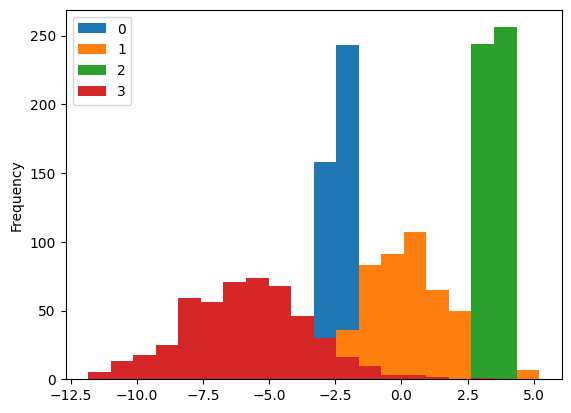

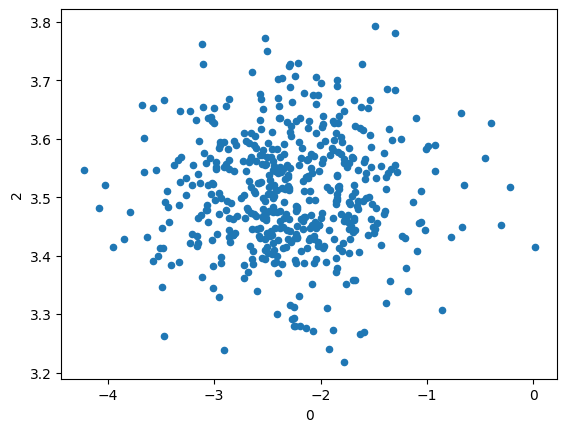

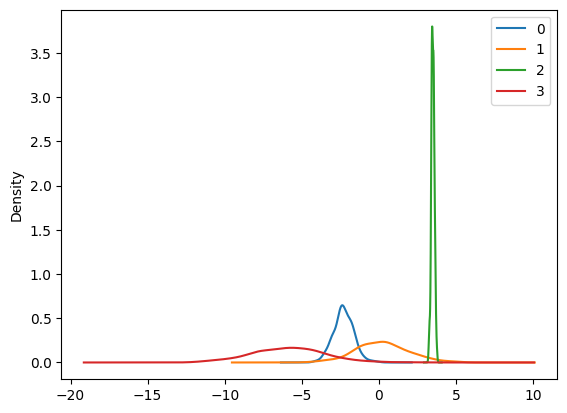

In [ ]:
rows = 500
cols = 4

A = np.zeros((rows, cols))

# custom normal density for each column
A[:,0] = np.random.normal(loc = -2.3, scale = 0.6, size = (rows, ))
A[:,1] = np.random.normal(loc = .3, scale = 1.7, size = (rows, ))
A[:,2] = np.random.normal(loc = 3.5, scale = 0.1, size = (rows, ))
A[:,3] = np.random.normal(loc = -5.73, scale = 2.3, size = (rows, ))
df = pd.DataFrame(A)

display(df.describe())

# histogram of every column
df.plot.hist(bins = 20)

# scatter plot of the 2 first columns
df.plot.scatter(x = 0, y = 2)

# density plot of every column
df.plot.density()

**pandas** is a rich library with a lot of possibilities, we recommend you to go look at the [documentation](https://pandas.pydata.org/docs/) for more details. This also means we cannot cover all the tools provided by **pandas**, you will have to look for yourself when dealing with your own problems and data.

## Selection on DataFrames

One of the best tool of pandas is the capacity to perform data treatment easily, slicing, selecting, removing or adding element are a core part of a **DataFrame**.

We saw how to access data using column or row index, with that we can also apply selection on the data. 

We will be using seaborn's [penguis](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv) toy dataset in the next examples. **pandas** is equipped with a lot of loader for different kind of data, most of them follow the naming scheme: `read_***` where the format is at the end.

Here we load the data as;

In [ ]:
penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
display(penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


These data are also important to learn how to take care of missing data, like **NaN** (Not a Number) or **null** values.

We can apply conditionnal selection like;

In [ ]:
male_penguins = penguins[ penguins["sex"] == "MALE" ]
display(male_penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,MALE
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,MALE
...,...,...,...,...,...,...,...
333,Gentoo,Biscoe,51.5,16.3,230.0,5500.0,MALE
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,MALE
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,MALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE


Inside the first bracket is what is called a **mask**, it's a **Slice** that contains boolean values resulting from the selection we did, here selecting only male. This **mask** tell pandas to only keep entry with index with a **True** value, allowing us to select quite efficiently.

The selection can be more complex, adding **and**, **or**, **not** operator or custon functions.

To use logical operator, you can't simply use standard Python ones, you have to use specific **pandas** one:

* **and** -> **&**
* **or** -> **|**
* **not** -> **~**
* **xor** -> **^**

Here we select even more the individuals.


In [ ]:
gentoo_male_penguins = penguins[ (penguins["sex"] == "MALE") &
                                 (penguins["species"] == "Gentoo") &
                                 (penguins["body_mass_g"] > 5500.0)
                               ]
display(gentoo_male_penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE
231,Gentoo,Biscoe,49.0,16.1,216.0,5550.0,MALE
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,MALE
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,MALE
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,MALE
240,Gentoo,Biscoe,50.2,14.3,218.0,5700.0,MALE
247,Gentoo,Biscoe,47.8,15.0,215.0,5650.0,MALE
249,Gentoo,Biscoe,50.0,15.3,220.0,5550.0,MALE
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,MALE


You can also use the `query` operation, taking a string as input and need to be formatted as:

In [ ]:
gentoo_male_penguins = penguins.query("sex == 'MALE' and species == 'Gentoo' and body_mass_g > 5500.0 ")
display(gentoo_male_penguins)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE
231,Gentoo,Biscoe,49.0,16.1,216.0,5550.0,MALE
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,MALE
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,MALE
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,MALE
240,Gentoo,Biscoe,50.2,14.3,218.0,5700.0,MALE
247,Gentoo,Biscoe,47.8,15.0,215.0,5650.0,MALE
249,Gentoo,Biscoe,50.0,15.3,220.0,5550.0,MALE
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,MALE


Both methods are valid to use, `query` is a little bit faster than the `[]` operator with very large **DataFrame** (starting at 200,000 rows) and have some advantages in advanced scenario, for now it's equivalent.

You can also create new column using other ones as input, simple case can be written as

In [ ]:
gentoo_male_penguins["body_mass_kg"] = gentoo_male_penguins["body_mass_g"] / 1000.0
display(gentoo_male_penguins)

# The warning given here is a false positive, do not take it into account.

C:\Users\josev\AppData\Local\Temp\ipykernel_17880\1041198442.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gentoo_male_penguins["body_mass_kg"] = gentoo_male_penguins["body_mass_g"] / 1000.0


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,body_mass_kg
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE,5.70
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE,5.70
231,Gentoo,Biscoe,49.0,16.1,216.0,5550.0,MALE,5.55
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,MALE,5.85
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,MALE,5.85
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,MALE,6.30
240,Gentoo,Biscoe,50.2,14.3,218.0,5700.0,MALE,5.70
247,Gentoo,Biscoe,47.8,15.0,215.0,5650.0,MALE,5.65
249,Gentoo,Biscoe,50.0,15.3,220.0,5550.0,MALE,5.55
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,MALE,6.05


For even more complex function, one could use the `apply()` function to use a user defined function, it has more power but is also more complex. Here's an exemple in which we want to create a column conditionaly in regards of other columns;

In [ ]:
def custom_weight_function(weight) :
    
    t = "Unknown"
    if weight < 5300.0 :
        t = "Small"
    elif weight < 5700.0 : 
        t = "Medium"
    elif weight >= 5700.0 :
        t = "Big"
        
    return t

gentoo_male_penguins = penguins.query("sex == 'MALE' and species == 'Gentoo'")
gentoo_male_penguins["Type"] = gentoo_male_penguins["body_mass_g"].apply(custom_weight_function)
display(gentoo_male_penguins)

C:\Users\josev\AppData\Local\Temp\ipykernel_17880\2461701141.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gentoo_male_penguins["Type"] = gentoo_male_penguins["body_mass_g"].apply(custom_weight_function)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Type
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,MALE,Big
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,MALE,Big
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,MALE,Medium
227,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,MALE,Small
229,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,MALE,Small
...,...,...,...,...,...,...,...,...
333,Gentoo,Biscoe,51.5,16.3,230.0,5500.0,MALE,Medium
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,MALE,Big
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,MALE,Big
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE,Big


## Exercise 4

We will use seaborn's [planets](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv) toy dataset for the next exercise.

* Display a summary of the statistical distribution of the data.

* Select planets discovered between 1999 and 2014 and plot the distribution of there masses.

* Plot the distribution of masses in function of the distance

* Select all planets discovered with the "Transit" method, orbital period inferior to 150 and distance inferior to 4000. Plot the orbital period in function of the distance.

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


<Axes: xlabel='distance', ylabel='orbital_period'>

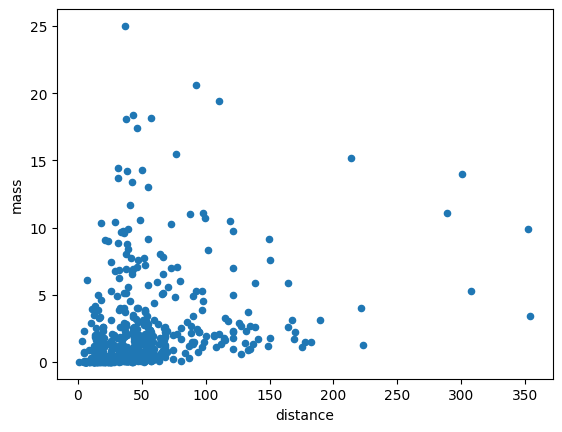

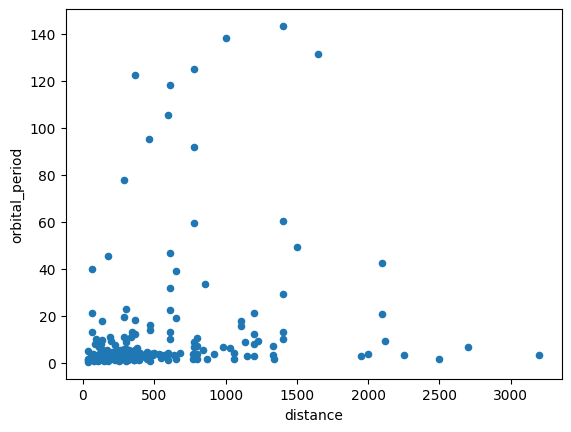

In [ ]:
# Exercise 4
planets = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv')
display(planets)
display(planets.describe())
date_limited = planets.query("year >= 1999 and year <= 2014")
display(date_limited)

planets.plot.scatter(x=4, y=3)

planet_very_limited = planets.query("distance < 4000 and orbital_period < 150 and method == 'Transit'")
planet_very_limited.plot.scatter(x=4, y = 2)

### Simple linear regression model using **scikit-learn**

We start with perhaps our simplest possible example, using **Scikit-Learn** to perform linear regression analysis on a data set produced by us. 

What follows is a simple Python code where we have defined a function
$y$ in terms of the variable $x$. Both are defined as vectors with  $100$ entries. 
The numbers in the vector $\boldsymbol{x}$ are given
by random numbers generated with a uniform distribution with entries
$x_i \in [0,1]$. These values are then used to define a function $y(x)$
(tabulated again as a vector) with a linear dependence on $x$ plus a
random noise added via the normal distribution.

With the **NumPy** function **randn()** we can compute random
numbers with the normal distribution (mean value $\mu$ equal to zero and
variance $\sigma^2$ set to one) and produce the values of $y$ assuming a linear
dependence as function of $x$

$$
y = -3x + 4 + N(0,1)
$$

where $N(0,1)$ represents random numbers generated by the normal
distribution.  From **Scikit-Learn** we import then the
**LinearRegression** functionality and make a prediction $\tilde{y} =
\alpha + \beta x$ using the function **fit(x,y)**. We call the set of
data $(\boldsymbol{x},\boldsymbol{y})$ for our training data. The Python package
**scikit-learn** has also a functionality which extracts the above
fitting parameters $\alpha$ and $\beta$ (see below). Later we will
distinguish between training data and test data.

For plotting we use the Python package
[matplotlib](https://matplotlib.org/) which produces publication
quality figures. Feel free to explore the extensive
[gallery](https://matplotlib.org/gallery/index.html) of examples. In
this example we plot our original values of $x$ and $y$ as well as the
prediction **ypredict** ($\tilde{y}$), which attempts at fitting our
data with a straight line.

The Python code follows here.

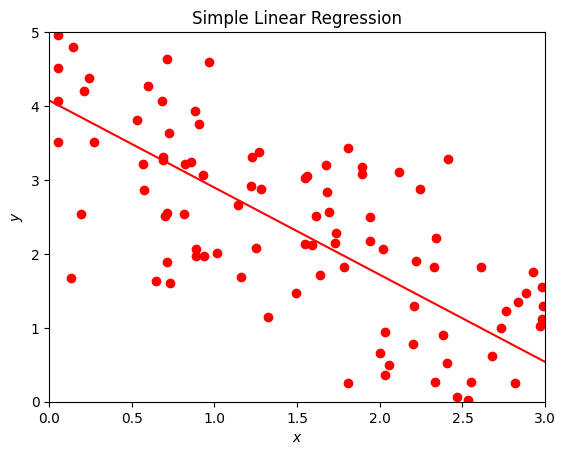

In [ ]:
# Importing various packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.random.rand(100,1) * 3
y = -1.2 * x + 4 + np.random.randn(100,1) 

linreg = LinearRegression()
linreg.fit(x,y)
xnew = np.array([[0],[3]])
ypredict = linreg.predict(xnew)

plt.plot(xnew, ypredict, "r-")
plt.plot(x, y ,'ro')
plt.axis([0,3.0,0, 5.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Simple Linear Regression')
plt.show()

### Linear regression with scipy

Another very popular library used for fundamental algorithms is [SciPy](https://scipy.org/), we can do the previous exercise using this library. We will use the `curve_fit` function to perform the same fit on a new function.

$$
y = -2.5x^2 + 1.4x - 2.6 + N(0,1)
$$

Fitted parameters: [-2.4899353   1.37285528 -2.66140902]
Error on fitted parameters: [0.03909224 0.06116093 0.16051117]


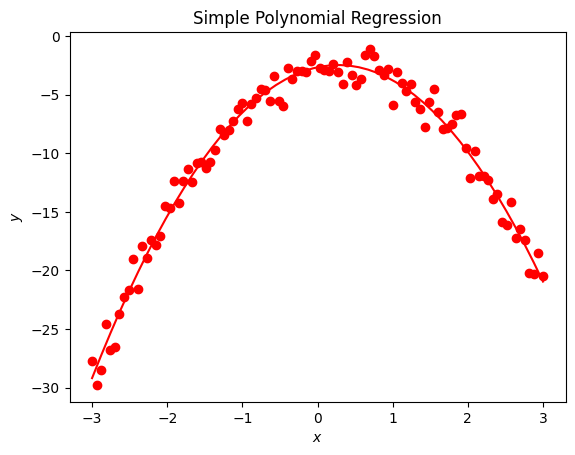

In [43]:
from scipy.optimize import curve_fit

# user define function to be fitted, can be anything!

# WORKS: write the function according to the documentation
def model(x , a , b , c) :
    return a*x**2 + b*x + c

# generate the data, note the change of shape and boundaries
x = np.random.rand(100) * 6 - 3
x = np.linspace(-3, 3, 100)
y = -2.5 * x ** 2 + 1.4 * x - 2.6 + np.random.randn(100) 

# Initial guess, helps to fit the data
p0 = [-1, 3, 3]

# Fit
popt, pcov = curve_fit(model, x, y, p0 = p0)
perr = np.sqrt(np.diag(pcov))
print(f"Fitted parameters: {popt}")
print(f"Error on fitted parameters: {perr}")

# Plot the result
xnew = np.linspace(-3, 3, 50)
ypred = [model(i, *popt) for i in xnew]

plt.plot(xnew, ypred, "r-")
plt.plot(x, y ,'ro')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Simple Polynomial Regression')
plt.show()

## Exercise 5

We will use seaborn's [seaice](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/seaice.csv) toy dataset for the next exercise.

* Display the extension of ice in function of time.

* Create a new column and convert the time and date in Unix seconds.

* Extract data as numpy arrays.

* Use a linear regression to fit the data.

* Predict the time when the ice should totally melt.

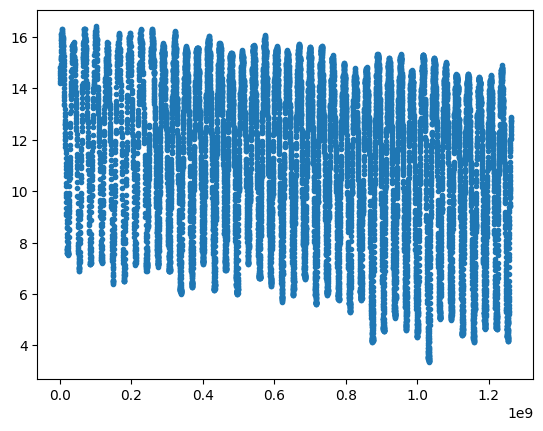

In [65]:
# Exercise 5

seaice = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/seaice.csv')

seaice["seconds"] = pd.to_datetime(seaice["Date"])
seaice["seconds"] = (seaice["seconds"] - seaice["seconds"][0]).dt.total_seconds()

extent = np.array(seaice["Extent"])
seconds = np.array(seaice["seconds"])


from scipy.stats import linregress

res = linregress(seconds , extent)
plt.scatter( seconds , extent , marker = ".")
#plt.plot(seconds , res.slope * seconds + res.intercept)
plt.show()

## Advanced Section

In experimental physics (nuclear reactions, high-energy collisions, astroparticles), detectors can record spatial ionization hits $(x, y, z)$ or energy depositions. Reconstructing events requires:
* Grouping hits that belong to the same particle trajectory (**track reconstruction**).
* Grouping energy deposits in calorimeter cells (**shower clustering**).
* Identifying electronic noise or background beam hits.

Unlike supervised tasks, we rarely have ground-truth event labels during live online data acquisition. This is the realm of **Unsupervised Clustering**.

### Geometric Inductive Biases: K-Means vs. DBSCAN
Every machine learning algorithm possesses an **inductive bias** — a set of implicit mathematical assumptions about the geometry of the data:

1. **K-Means (Centroid-based, Spherical Bias)**:
   * Assumes clusters are convex, isotropic (spherical) clouds centered around centroids $\boldsymbol{\mu}_k$.
   * Minimizes within-cluster variance (Euclidean inertia):
     $$J = \sum_{k=1}^K \sum_{\mathbf{x} \in C_k} \|\mathbf{x} - \boldsymbol{\mu}_k\|^2$$

2. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**:
   * Defines clusters as continuous regions of high point density separated by low-density regions.
   * Parameters:
     - $\varepsilon$ (eps): Radius of the spatial neighborhood.
     - `min_samples`: Minimum number of hits required to form a dense core point.
     - Can follow arbitrary non-convex geometries.
     - Automatically flags outliers (label `-1`).

---

### Exercise 6: Inductive Biases on Complex Manifolds (SIPU Spiral Benchmark)

We will use the classic **SIPU Spiral Benchmark dataset**, which consists of 3 intertwined spirals.

**Your Tasks:**
1. Load the SIPU spiral dataset from `https://cs.joensuu.fi/sipu/datasets/spiral.txt`.
2. Apply **K-Means** with $k=3$.
3. Apply **DBSCAN** (tune $\varepsilon$ around $2.0 - 2.5$ with `min_samples=3`).
4. Plot a side-by-side comparison (3 subplots):
   - Subplot 1: Ground Truth clusters.
   - Subplot 2: K-Means clustering result (include cluster centroids as red 'X' markers).
   - Subplot 3: DBSCAN clustering result.
5. *(Bonus)*: Add 25 uniform random noise hits across the coordinate range. Re-run DBSCAN and highlight how it tags and isolates noise hits.
6. Try on other datasets from [page link](`https://cs.joensuu.fi/sipu/datasets/`)

**Questions for Reflection:**
* Why does K-Means cut across the spiral arms instead of following them?

In [46]:
# Exercise 7: K-Means vs DBSCAN on the SIPU Spiral Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# 1. Load the SIPU spiral benchmark dataset
url_spiral = "https://cs.joensuu.fi/sipu/datasets/spiral.txt"
spiral = pd.read_csv(url_spiral, sep=r"\s+", header=None, names=["x", "y", "true_cluster"])
X_spiral = spiral[["x", "y"]].values

# TODO: Fit KMeans with k=3
# kmeans = KMeans(n_clusters=3, random_state=42).fit(...)
# kmeans_labels = ...

# TODO: Fit DBSCAN (tune eps between 2.0 and 2.5, min_samples=3)
# dbscan = DBSCAN(eps=..., min_samples=3).fit(...)
# dbscan_labels = ...

# TODO: Plot 3 subplots:
# Subplot 1: Ground Truth
# Subplot 2: K-Means result + centroids
# Subplot 3: DBSCAN result


# TODO (Bonus): Detector Noise Simulation
# np.random.seed(42)
# noise = np.random.uniform(low=..., high=..., size=(25, 2))
# X_with_noise = np.vstack([X_spiral, noise])
# Fit DBSCAN and plot the result highlighting noise hits (label == -1)
